# Task 5: Traffic Recommendation System

Turns the Task 1 models into a small, queryable **route-timing** recommendation system: given a day type (weekday / weekend / holiday) and, optionally, a weather condition, it predicts expected traffic volume *and* accident-risk for every hour of the day and recommends a suitable, lower-traffic travel window in plain language — e.g. *"For a weekday journey, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower."*

**Scope note:** this dataset covers a single corridor (Metro Interstate), not a road network — there is no alternative route to recommend, only alternative *timing*. So "recommendation" here means **when** to travel, not **which way**. A route-choice version of this system would need additional road-segment data.

**How it works, in one paragraph:** rather than just reporting historical averages, the system re-trains the Task 1 regressor (traffic volume) and classifier (accident-risk proxy) on the full engineered feature set, then generates a synthetic row for every hour of the day under the requested day type and weather, predicts both targets for each, and picks the lowest-traffic hour — with a safety check that flags (and, where possible, offers an alternative to) any recommended hour whose predicted accident-risk is still notably elevated.

## 1. Imports

In [1]:
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

RANDOM_STATE = 42

## 2. Logging setup

Same dual-handler pattern (DEBUG+ to `pipeline.log`, INFO+ inline) used throughout the other notebooks, with the re-run guard needed because notebook cells — unlike scripts — can be executed more than once per kernel session.

In [2]:
logger = logging.getLogger("task5_recommender")


def setup_logging():
    if logger.handlers:
        return  # guard against duplicate handlers if this cell is re-run
    logger.setLevel(logging.DEBUG)
    fmt = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )

    fh = logging.FileHandler("pipeline.log", mode="a", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(fmt)

    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)
    ch.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(ch)
    logger.propagate = False


setup_logging()
logger.info("Logging initialised")

2026-09-24 21:53:23 | INFO | task5_recommender | Logging initialised


## 3. Load data and rebuild the Task 1 feature set / targets

In [4]:
FEATURES_PATH = "Features_Metro_Interstate_Traffic_Volume.csv"

df = pd.read_csv(FEATURES_PATH, parse_dates=["date_time"])
logger.info("Loaded %s rows, %s columns from %s", len(df), df.shape[1], FEATURES_PATH)

# --- is_holiday flag ---
is_holiday = df["holiday"].notna() & (df["holiday"] != "None")
df["is_holiday"] = is_holiday.astype(int)

# --- accident_risk proxy label (congestion + adverse weather), same as Task 1 ---
congestion_cutoff = df["traffic_volume"].quantile(2 / 3)
is_congested = df["traffic_volume"] >= congestion_cutoff
is_adverse_weather = (
    (df["is_severe_weather"] == 1) | (df["is_precipitation"] == 1) | (df["is_overcast"] == 1)
)
df["accident_risk"] = (is_congested & is_adverse_weather).astype(int)

# --- Shared feature set (traffic_volume and anything derived from it excluded — see Task 1) ---
time_features = [
    "hour", "day_of_week", "is_weekend",
    "hour_sin", "hour_cos", 
]
exclude_raw_text = {"weather_main", "weather_description"}
weather_onehot = sorted(
    c for c in df.columns if c.startswith("weather_") and c not in exclude_raw_text
)
weather_derived = [
    "is_precipitation", "total_precipitation", "is_overcast",
    "is_clear", "is_severe_weather", "clouds_all", "temp_c",
]
feature_cols = time_features + weather_onehot + weather_derived + ["is_holiday"]

model_df = df[feature_cols + ["traffic_volume", "accident_risk"]].dropna()
logger.info("Modelling on %s rows, %s features", len(model_df), len(feature_cols))

2026-09-24 21:53:34 | INFO | task5_recommender | Loaded 48187 rows, 38 columns from Features_Metro_Interstate_Traffic_Volume.csv
2026-09-24 21:53:34 | INFO | task5_recommender | Modelling on 48187 rows, 24 features


## 4. Fit the models the recommender will query

Random Forest was the stronger performer for both targets in Task 1, so it's what powers the recommender. One deliberate difference from Task 1: those models were fit on an 80% train split so their *held-out* metrics would be trustworthy. Here the goal isn't evaluating generalisation again — Task 1 (and Task 4's MLflow-tracked runs) already did that — it's giving the recommender the best available estimate of typical hourly patterns, so both models are refit on the **full** dataset.

In [5]:
X = model_df[feature_cols]
y_reg = model_df["traffic_volume"]
y_clf = model_df["accident_risk"]

reg_model = RandomForestRegressor(
    n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
)
reg_model.fit(X, y_reg)

clf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
clf_model.fit(X, y_clf)

BASE_RISK_RATE = model_df["accident_risk"].mean()
logger.info("Recommender models fitted on the full dataset (%s rows). Base accident_risk rate: %.3f", len(model_df), BASE_RISK_RATE)

2026-09-24 21:53:50 | INFO | task5_recommender | Recommender models fitted on the full dataset (48187 rows). Base accident_risk rate: 0.136


## 5. Typical weather profile for a query

To predict traffic/risk for, say, *"a weekday hour under Rain"*, every feature column needs a value — including the weather ones. Rather than guessing plausible numbers by hand, this pulls the **empirical average feature vector** from every historical hour that actually had that `weather_main` category. That keeps every downstream prediction grounded in what the condition really looks like in this data (e.g. `Rain` hours really do have `is_precipitation` ≈ 1, a realistic typical `clouds_all`, etc.) rather than an invented approximation.

**Matching category → one-hot column without assuming a naming convention:** `weather_onehot` (section 3) already found the right columns for the model regardless of what prefix `engineer_weather_features()` used (`weather_main_Clear`, `weather_Clear`, ...). To label them with the actual category names, each column is matched against the raw `weather_main` text column directly — whichever one-hot column is `1` on every row of a given category **is** that category — instead of re-guessing the naming convention a second time.

In [6]:
def _map_weather_categories():
    """{category name -> its actual one-hot column}, discovered from the data rather than assumed."""
    mapping = {}
    for category in sorted(df["weather_main"].dropna().unique()):
        subset = df.loc[df["weather_main"] == category, weather_onehot]
        matches = subset.columns[(subset == 1).all(axis=0)]
        if len(matches) == 1:
            mapping[str(category)] = matches[0]
        else:
            logger.warning(
                "Could not uniquely match weather_main=%r to a one-hot column (%d candidates); skipping",
                category, len(matches),
            )
    return mapping


WEATHER_CATEGORY_TO_COLUMN = _map_weather_categories()
if not WEATHER_CATEGORY_TO_COLUMN:
    raise RuntimeError(
        "Could not match any weather_main category to a one-hot column in feature_cols. Check that "
        "engineer_weather_features() one-hot-encoded weather_main and that those columns are still "
        "present in the features CSV."
    )
logger.info("Weather categories detected: %s", sorted(WEATHER_CATEGORY_TO_COLUMN))

WEATHER_COLS = weather_onehot + [
    "is_precipitation", "total_precipitation", "is_overcast",
    "is_clear", "is_severe_weather", "clouds_all", "temp_c",
]


def weather_profile(weather_main_value):
    """Average feature vector for every historical hour with this weather_main category."""
    col = WEATHER_CATEGORY_TO_COLUMN.get(weather_main_value)
    if col is None:
        raise ValueError(
            f"Unknown weather condition {weather_main_value!r}. "
            f"Available: {sorted(WEATHER_CATEGORY_TO_COLUMN)}"
        )
    matches = model_df[model_df[col] == 1]
    if matches.empty:
        raise ValueError(f"No historical hours found for weather_main={weather_main_value!r}.")
    return matches[WEATHER_COLS].mean()

2026-09-24 21:53:50 | INFO | task5_recommender | Weather categories detected: ['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']


## 6. Predicted traffic + risk, by hour, for a (day type, weather) query

`weekday` averages Mon–Fri, `weekend` averages Sat/Sun, `holiday` averages every day of week with `is_holiday=1` — each hour's prediction is the mean across the days in that group, using the exact cyclical encodings from Task 1's `feature_engineering.py` (`sin`/`cos` of `2π·hour/24` and `2π·day_of_week/7`) so the synthetic rows match what the models were actually trained on.

If no `weather` is given, the profile is a frequency-weighted blend across **every** observed weather category (weighted by how often each occurs historically) — a genuinely weather-agnostic "typical day" estimate, rather than silently defaulting to one condition.

In [7]:
DAY_TYPES = {
    "weekday": {"days": [0, 1, 2, 3, 4], "is_weekend": 0, "is_holiday": 0},
    "weekend": {"days": [5, 6], "is_weekend": 1, "is_holiday": 0},
    "holiday": {"days": [0, 1, 2, 3, 4, 5, 6], "is_weekend": 0, "is_holiday": 1},
}


def _hourly_profile_for_weather(day_type, weather_main_value):
    if day_type not in DAY_TYPES:
        raise ValueError(f"day_type must be one of {list(DAY_TYPES)}, got {day_type!r}")
    cfg = DAY_TYPES[day_type]
    w_profile = weather_profile(weather_main_value)

    rows = []
    for day in cfg["days"]:
        for hour in range(24):
            row = {c: 0 for c in feature_cols}
            row.update(w_profile.to_dict())
            row["hour"] = hour
            row["day_of_week"] = day
            row["is_weekend"] = cfg["is_weekend"]
            row["is_holiday"] = cfg["is_holiday"]
            row["hour_sin"] = np.sin(2 * np.pi * hour / 24)
            row["hour_cos"] = np.cos(2 * np.pi * hour / 24)
            row["day_of_week_sin"] = np.sin(2 * np.pi * day / 7)
            row["day_of_week_cos"] = np.cos(2 * np.pi * day / 7)
            rows.append(row)

    grid = pd.DataFrame(rows)[feature_cols]
    grid["predicted_volume"] = reg_model.predict(grid[feature_cols])
    grid["predicted_accident_risk"] = clf_model.predict_proba(grid[feature_cols])[:, 1]
    grid["hour"] = grid["hour"].astype(int)

    hourly = grid.groupby("hour")[["predicted_volume", "predicted_accident_risk"]].mean()
    return hourly.reindex(range(24))


def build_hourly_profile(day_type, weather=None):
    if weather is not None:
        return _hourly_profile_for_weather(day_type, weather)

    # weather-agnostic: frequency-weighted blend across every observed category
    blended = None
    total_weight = 0.0
    for cat, col in WEATHER_CATEGORY_TO_COLUMN.items():
        w = model_df[col].mean()
        if w <= 0:
            continue
        profile = _hourly_profile_for_weather(day_type, cat) * w
        blended = profile if blended is None else blended + profile
        total_weight += w
    return blended / total_weight

## 7. Pick a suitable travel window

**Why restrict the search to `06:00–20:59`:** with no constraint at all, "lowest predicted traffic" trivially points at 2–4 AM every single time — true, but not a *suitable* answer for someone actually deciding when to make a daytime trip. Restricting the search to realistic travel hours surfaces a genuinely useful lull instead (e.g. the post-evening-rush trough around 8–9 PM). Pass `search_hours=range(24)` for a traveller who is genuinely flexible on timing.

**Why the risk check rarely changes the answer:** the `accident_risk` proxy label from Task 1 is defined as *congestion AND adverse weather* — and this function already selects for **low-traffic** (i.e. non-congested) hours. So a low-traffic recommendation is, by construction, usually also a low-predicted-risk one already. The check below is kept as a genuine safety net (the Random Forest is a smooth function of the inputs, not a hard rule, so it's not *guaranteed* to track that relationship perfectly at every hour) rather than something expected to fire often — and the demo in section 8 includes an example where it does.

In [8]:
DEFAULT_SEARCH_HOURS = range(6, 21)  # 06:00-20:59: realistic daytime/evening travel hours


def recommend_window(day_type, weather=None, risk_multiplier=1.5, search_hours=DEFAULT_SEARCH_HOURS):
    hourly = build_hourly_profile(day_type, weather)
    risk_threshold = BASE_RISK_RATE * risk_multiplier

    candidates = hourly.loc[list(search_hours)]
    ranked = candidates.sort_values("predicted_volume")
    best_hour = ranked.index[0]
    best_row = ranked.iloc[0]

    elevated_risk = bool(best_row["predicted_accident_risk"] > risk_threshold)
    safer_alt = ranked[ranked["predicted_accident_risk"] <= risk_threshold]

    if elevated_risk and not safer_alt.empty:
        alt_hour = safer_alt.index[0]
        alt_row = safer_alt.loc[alt_hour]
    else:
        alt_hour, alt_row = None, None

    result = {
        "day_type": day_type,
        "weather": weather,
        "hourly_profile": hourly,
        "best_hour": int(best_hour),
        "best_volume": float(best_row["predicted_volume"]),
        "best_risk": float(best_row["predicted_accident_risk"]),
        "elevated_risk": elevated_risk,
        "alt_hour": int(alt_hour) if alt_hour is not None else None,
        "alt_volume": float(alt_row["predicted_volume"]) if alt_row is not None else None,
        "alt_risk": float(alt_row["predicted_accident_risk"]) if alt_row is not None else None,
        "base_risk_rate": float(BASE_RISK_RATE),
    }
    logger.debug(
        "[Recommend] %s/%s -> hour %s (vol %.0f, risk %.3f, elevated=%s)",
        day_type, weather, result["best_hour"], result["best_volume"], result["best_risk"], elevated_risk,
    )
    return result

## 8. Generate the plain-language recommendation

In [9]:
def format_hour(h):
    h = int(h) % 24
    period = "AM" if h < 12 else "PM"
    display = h % 12
    display = 12 if display == 0 else display
    return f"{display}:00 {period}"


def generate_recommendation(result):
    day_type = result["day_type"]
    weather = result["weather"]
    start_h = result["best_hour"]
    end_h = (start_h + 1) % 24
    weather_phrase = f" in {weather.lower()} conditions" if weather else ""

    sentence = (
        f"For a {day_type} journey{weather_phrase}, consider travelling between "
        f"{format_hour(start_h)} and {format_hour(end_h)}, when traffic volumes are typically lower "
        f"(model estimate: ~{result['best_volume']:.0f} vehicles/hour)."
    )

    if result["elevated_risk"]:
        if result["alt_hour"] is not None:
            alt_start = result["alt_hour"]
            alt_end = (alt_start + 1) % 24
            sentence += (
                f" Note: this window still shows a somewhat elevated modelled accident-risk signal"
                f"{weather_phrase or ' for these conditions'} (reflecting the weather, not the low traffic "
                f"itself). If minimising risk matters more than minimising travel time, "
                f"{format_hour(alt_start)}\u2013{format_hour(alt_end)} carries a lower risk estimate, at "
                f"the cost of somewhat higher typical traffic (~{result['alt_volume']:.0f} vehicles/hour)."
            )
        else:
            sentence += (
                f" Note: every hour{weather_phrase or ' in this scenario'} shows an elevated modelled "
                f"accident-risk signal relative to the dataset average \u2014 this reflects the conditions "
                f"themselves, and no timing choice fully avoids it."
            )
    return sentence

## 9. The recommendation system

A thin, queryable wrapper around sections 5–8 — this is the object a downstream application (or a user) would actually import and call.

In [14]:
class TrafficRecommendationSystem:
    """Recommends a lower-traffic travel window for this corridor, given a day type and
    (optionally) a weather condition. Combines the Task 1 regression model (traffic volume)
    and classification model (accident-risk proxy) rather than only historical averages."""

    def available_weather_conditions(self):
        return sorted(WEATHER_CATEGORY_TO_COLUMN)

    def recommend(self, day_type, weather=None, **kwargs):
        result = recommend_window(day_type, weather, **kwargs)
        sentence = generate_recommendation(result)
        logger.info("[Recommender] %s / %s -> %s", day_type, weather, sentence)
        return result, sentence


recommender = TrafficRecommendationSystem()
logger.info(f"Available weather conditions: {recommender.available_weather_conditions()}")

2026-09-24 21:57:12 | INFO | task5_recommender | Available weather conditions: ['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']


## 10. Demo queries

A spread of day types and weather conditions, including one (`risk_multiplier=0.2`, a stricter safety tolerance) chosen specifically to demonstrate the risk-caveat / alternative-window branch of section 8 in action, not just the plain low-traffic case.

In [19]:
demo_queries = [
    dict(day_type="weekday", weather=None),
    dict(day_type="weekday", weather="Clear"),
    dict(day_type="weekday", weather="Rain"),
    dict(day_type="weekend", weather="Clear"),
    dict(day_type="weekday", weather="Snow"),
    dict(day_type="holiday", weather=None),
    dict(day_type="weekday", weather="Thunderstorm", risk_multiplier=0.2),  # forces the risk-caveat branch
]

for query in demo_queries:
    result, sentence = recommender.recommend(**query)
    label = f"{query['day_type']} / {query.get('weather') or 'any weather'}"
    logger.info(f"[{label}]")
    logger.info(sentence)
    logger.info("")

2026-09-24 21:58:14 | INFO | task5_recommender | [Recommender] weekday / None -> For a weekday journey, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower (model estimate: ~2830 vehicles/hour).
2026-09-24 21:58:14 | INFO | task5_recommender | [weekday / any weather]
2026-09-24 21:58:14 | INFO | task5_recommender | For a weekday journey, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower (model estimate: ~2830 vehicles/hour).
2026-09-24 21:58:14 | INFO | task5_recommender | 
2026-09-24 21:58:14 | INFO | task5_recommender | [Recommender] weekday / Clear -> For a weekday journey in clear conditions, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower (model estimate: ~2846 vehicles/hour).
2026-09-24 21:58:14 | INFO | task5_recommender | [weekday / Clear]
2026-09-24 21:58:14 | INFO | task5_recommender | For a weekday journey in clear conditions, consider travelling between 8:

## 11. Visualizing a recommendation

The predicted-volume curve behind one example recommendation, so it can be checked visually rather than taken on faith.

2026-09-24 21:58:28 | INFO | task5_recommender | [Recommender] weekday / Clear -> For a weekday journey in clear conditions, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower (model estimate: ~2846 vehicles/hour).


For a weekday journey in clear conditions, consider travelling between 8:00 PM and 9:00 PM, when traffic volumes are typically lower (model estimate: ~2846 vehicles/hour).


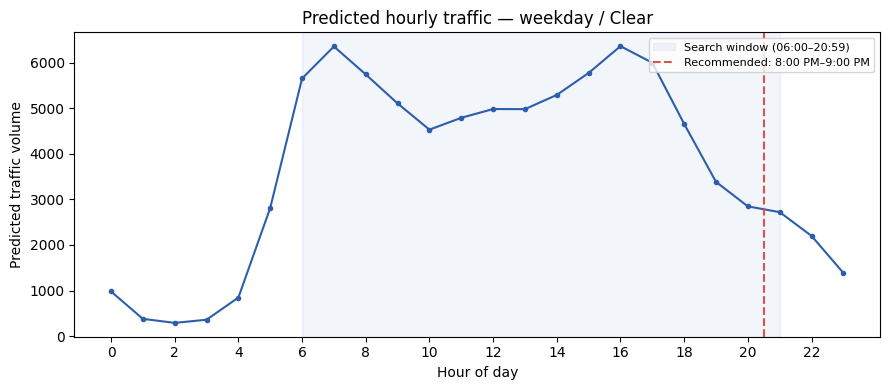

In [20]:
result, sentence = recommender.recommend("weekday", "Clear")
print(sentence)

hourly = result["hourly_profile"]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly["predicted_volume"], color="#2E5EAA", marker="o", markersize=3)
ax.axvspan(6, 21, color="#2E5EAA", alpha=0.06, label="Search window (06:00–20:59)")
ax.axvline(
    result["best_hour"] + 0.5, color="#D9534F", linestyle="--",
    label=f"Recommended: {format_hour(result['best_hour'])}–{format_hour(result['best_hour'] + 1)}",
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Predicted traffic volume")
ax.set_title(f"Predicted hourly traffic — {result['day_type']} / {result['weather']}")
ax.set_xticks(range(0, 24, 2))
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()